# PulseIQ — Heart Disease Model Training
### Author: Niranjana Devi P| Final Year B.E. CSE

## 1. Import Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pickle

## 2. Load & Explore Dataset


In [2]:
heart = pd.read_csv("heart_disease_uci.csv")
print("Shape:", heart.shape)
heart.head()

Shape: (920, 16)


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [3]:
heart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [4]:
print("Missing values:\n", heart.isnull().sum())

Missing values:
 id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64


## 3. Data Cleaning

In [5]:
heart.dropna(inplace=True)
print("Shape after dropping nulls:", heart.shape)

Shape after dropping nulls: (299, 16)


## 4. Encoding Categorical Variables

In [6]:
le = LabelEncoder()
for col in ['sex','dataset','cp','fbs','restecg','exang','slope','thal']:
    heart[col] = le.fit_transform(heart[col])
heart['num'] = heart['num'].apply(lambda x: 0 if x == 0 else 1)
heart.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,1,0,3,145.0,233.0,1,0,150.0,0,2.3,0,0.0,0,0
1,2,67,1,0,0,160.0,286.0,0,0,108.0,1,1.5,1,3.0,1,1
2,3,67,1,0,0,120.0,229.0,0,0,129.0,1,2.6,1,2.0,2,1
3,4,37,1,0,2,130.0,250.0,0,1,187.0,0,3.5,0,0.0,1,0
4,5,41,0,0,1,130.0,204.0,0,0,172.0,0,1.4,2,0.0,1,0


## 5. Feature Selection & Train-Test Split

In [7]:
x = heart[['age','sex','cp','trestbps','chol','thalch','exang','oldpeak','ca','thal']]
y = heart['num']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print("Train:", x_train.shape, "| Test:", x_test.shape)

Train: (239, 10) | Test: (60, 10)


## 6. Train Random Forest Model

In [8]:
model = RandomForestClassifier(n_estimators=1000, criterion='entropy', max_depth=10, random_state=42)
model.fit(x_train, y_train)


RandomForestClassifier(criterion='entropy', max_depth=10, n_estimators=1000,
                       random_state=42)

## 7. Evaluation

In [9]:
y_pred = model.predict(x_test)
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Train Accuracy:", model.score(x_train, y_train))


Test Accuracy: 0.8666666666666667
Train Accuracy: 1.0


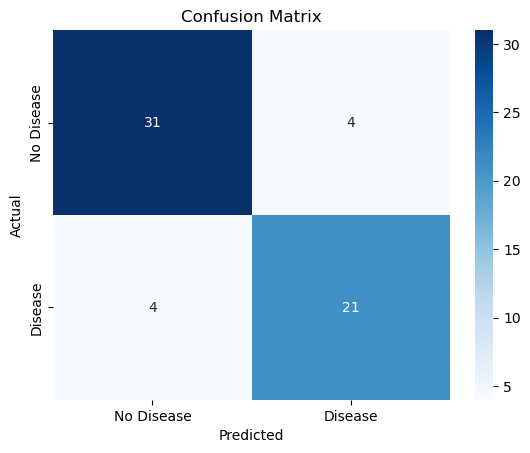

In [10]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease','Disease'],
            yticklabels=['No Disease','Disease'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [11]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.89      0.89        35
           1       0.84      0.84      0.84        25

    accuracy                           0.87        60
   macro avg       0.86      0.86      0.86        60
weighted avg       0.87      0.87      0.87        60



## 9. Save Model

In [12]:
import pickle
pickle.dump(model, open("heart_model.pkl", "wb"))
print("Model saved as heart_model.pkl")

Model saved as heart_model.pkl
